In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Shape:", df.shape)
print(df.head())
print(df.describe())



Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.00

In [3]:
print(df.isnull().sum())


MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64


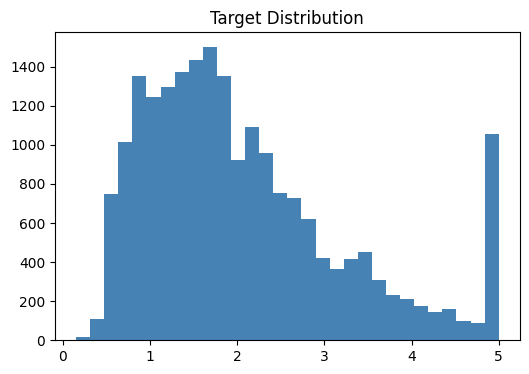

In [4]:
plt.figure(figsize=(6,4))
plt.hist(df['target'], bins=30, color='steelblue')
plt.title('Target Distribution')
plt.show()



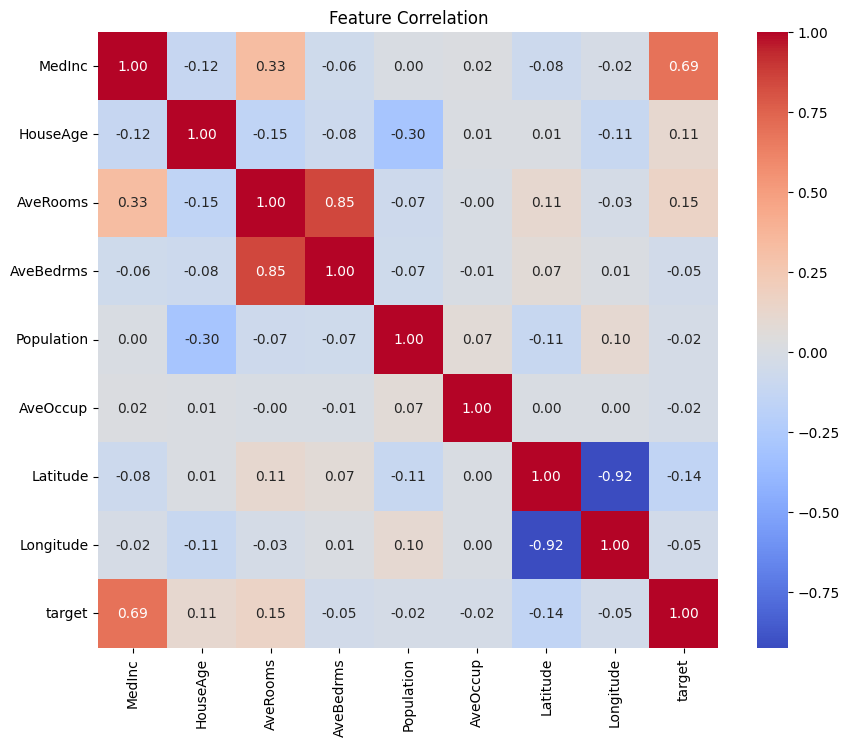

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()


In [6]:
X = df.drop('target', axis=1)
y = df['target']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

In [10]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print("Base Model R²:", r2_score(y_test, y_pred))
print("Base Model RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
# this will overfit — R² on train will be 1.0

Base Model R²: 0.6186632145457622
Base Model RMSE: 0.7068996727915191


In [11]:
print("Train R²:", r2_score(y_train, dt.predict(X_train)))
print("Test R² :", r2_score(y_test, y_pred))
# Train R² = 1.0, Test R² = low → classic overfitting



Train R²: 1.0
Test R² : 0.6186632145457622


In [12]:
depths = [2, 3, 4, 5, 6, 7, 8, 10]
train_scores = []
test_scores = []

In [13]:

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))



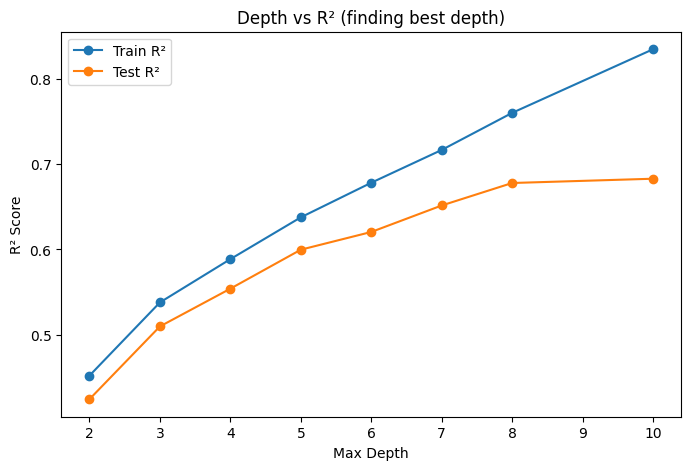

In [14]:
plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, label='Train R²', marker='o')
plt.plot(depths, test_scores, label='Test R²', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('Depth vs R² (finding best depth)')
plt.legend()
plt.show()


In [15]:
best_depth = depths[test_scores.index(max(test_scores))]
print("Best depth:", best_depth)

best_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print("Best Model R²  :", r2_score(y_test, y_pred_best))
print("Best Model RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))


Best depth: 10
Best Model R²  : 0.6829476865157171
Best Model RMSE: 0.6445682261497634


In [16]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print("CV Mean R²:", cv_scores.mean())
print("CV Std    :", cv_scores.std())


CV Mean R²: 0.6906257143726601
CV Std    : 0.00981867806026921


In [17]:
importance = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)



      Feature  Importance
0      MedInc    0.609776
5    AveOccup    0.131055
6    Latitude    0.080960
7   Longitude    0.065139
1    HouseAge    0.044300
2    AveRooms    0.039228
4  Population    0.016760
3   AveBedrms    0.012783


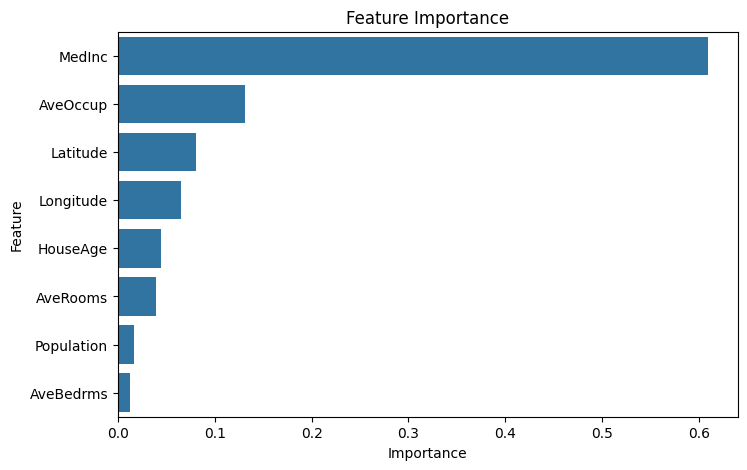

In [18]:
plt.figure(figsize=(8,5))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.show()



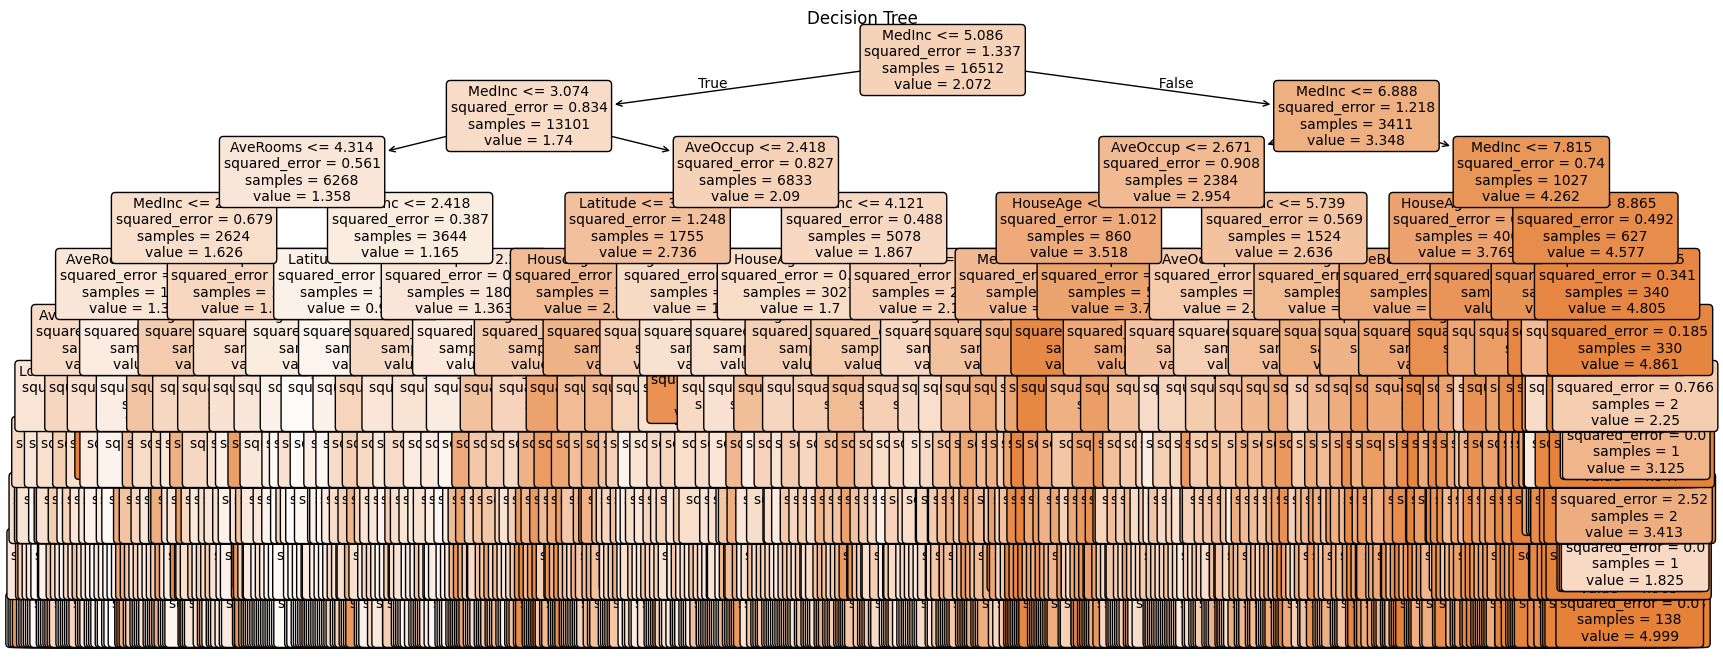

In [20]:
plt.figure(figsize=(20,8))
plot_tree(best_model, 
          feature_names=data.feature_names,
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree')
plt.show()


In [21]:
results = pd.DataFrame({
    'Model': ['Base DT (no depth limit)', f'Pruned DT (depth={best_depth})'],
    'R2 Score': [r2_score(y_test, y_pred), r2_score(y_test, y_pred_best)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred)),
             np.sqrt(mean_squared_error(y_test, y_pred_best))]
})
print(results)

                      Model  R2 Score      RMSE
0  Base DT (no depth limit)  0.618663  0.706900
1      Pruned DT (depth=10)  0.682948  0.644568
